=== Theoretical (series RLC) ===
lambda (representative) = -10+447.102j
f_d = 71.1585 Hz, zeta = 0.0223607

=== Continuous-time chosen mode (from A eigs) ===
lambda = -10+447.102j
sigma=-10 1/s, f=71.1585 Hz, zeta=0.0223607

=== Preview (few dt points) ===
      dt  f_ref_hz  f_hat_hz  f_hat_shifted_hz  zeta_ref  zeta_hat  zeta_hat_shifted
0.000010 71.158458 71.158340         71.158455  0.022361  0.022361          0.022361
0.000429 71.158458 70.941622         71.152818  0.022361  0.022225          0.022344
0.023300 71.158458 18.869535         63.651799  0.022361  0.002997          0.007339
1.000000 71.158458  0.498577         50.495239  0.022361  0.000064          0.000007


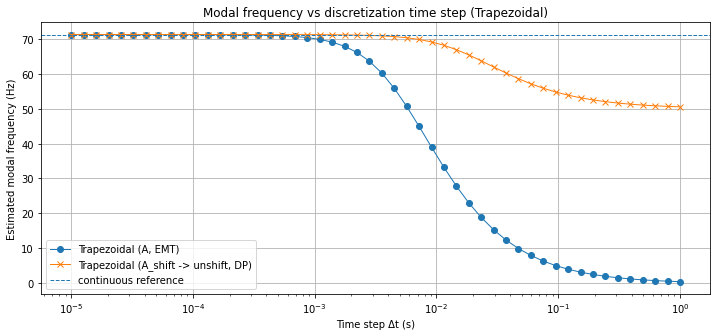

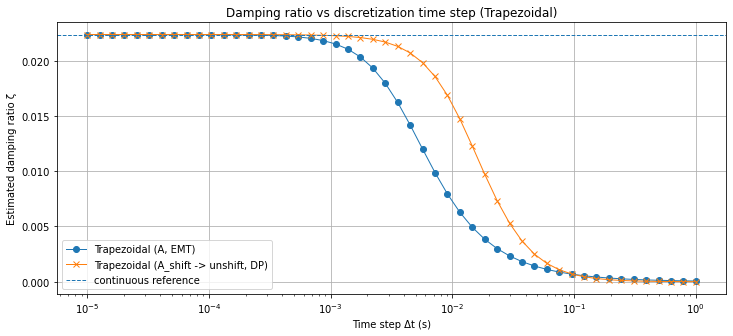

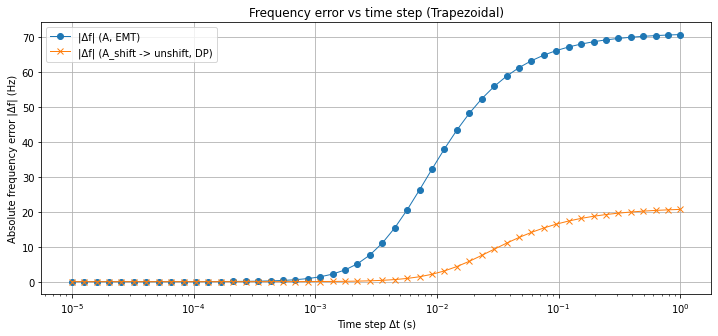

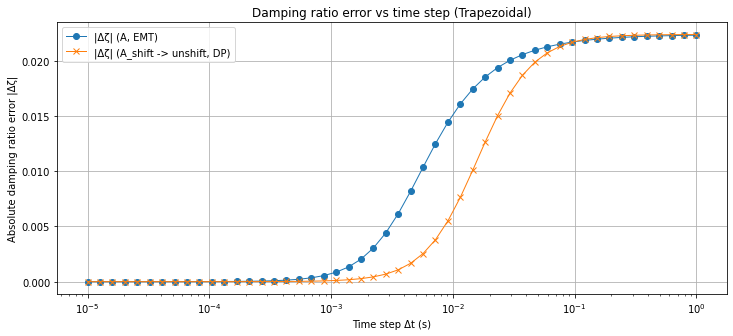

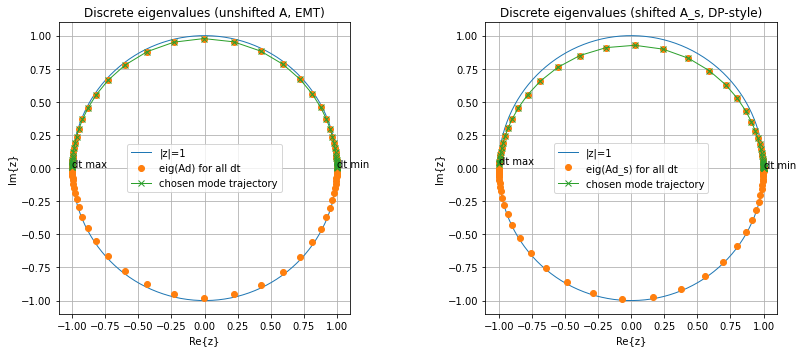

,dt,sigma_ref,f_ref_hz,zeta_ref,sigma_hat,f_hat_hz,zeta_hat,z_mode,z_all,sigma_hat_shifted,f_hat_shifted_hz,zeta_hat_shifted,z_mode_shift,z_all_shift
0,0.000010,-10.0,71.158458,0.022361,-9.999950,71.158340,0.022361,0.999890+0.004471j,"[(0.9998900115487876+0.00447054837364369j), (0...",-9.999996,71.158455,0.022361,0.999899+0.001329j,"[(0.9998710338465782-0.0076117389633231225j), ..."
1,0.000013,-10.0,71.158458,0.022361,-9.999920,71.158269,0.022361,0.999858+0.005654j,"[(0.9998575350504906+0.005654429730290733j), (...",-9.999993,71.158453,0.022361,0.999872+0.001681j,"[(0.9998271749690578-0.009627409105276707j), (..."
2,0.000016,-10.0,71.158458,0.022361,-9.999872,71.158155,0.022360,0.999814+0.007152j,"[(0.9998144507086886+0.0071517610756896j), (0....",-9.999989,71.158450,0.022361,0.999838+0.002127j,"[(0.9997658822162242-0.012176701460909323j), (..."
3,0.000020,-10.0,71.158458,0.022361,-9.999795,71.157973,0.022360,0.999757+0.009045j,"[(0.9997567460897329+0.009045489658389028j), (...",-9.999982,71.158446,0.022361,0.999794+0.002690j,"[(0.9997940439950295+0.002689661754566308j), (..."
4,0.000026,-10.0,71.158458,0.022361,-9.999673,71.157683,0.022360,0.999679+0.011440j,"[(0.999678625136573+0.011440481278969683j), (0...",-9.999971,71.158438,0.022361,0.999738+0.003402j,"[(0.9995543393085916-0.019478006666261226j), (..."
5,0.000032,-10.0,71.158458,0.022361,-9.999476,71.157218,0.022360,0.999572+0.014469j,"[(0.9995716040740339+0.014469287596935998j), (...",-9.999954,71.158426,0.022361,0.999667+0.004303j,"[(0.9996670491574263+0.004302544438694267j), (..."
6,0.000041,-10.0,71.158458,0.022361,-9.999162,71.156473,0.022359,0.999423+0.018299j,"[(0.9994231097991421+0.01829941035068494j), (0...",-9.999926,71.158407,0.022361,0.999576+0.005442j,"[(0.9995757835949708+0.005441614139826689j), (..."
7,0.000052,-10.0,71.158458,0.022361,-9.998660,71.155283,0.022359,0.999214+0.023142j,"[(0.9992142952966451+0.02314243261851212j), (0...",-9.999882,71.158376,0.022360,0.999458+0.006882j,"[(0.9987057561097376-0.0393936055006579j), (0...."
8,0.000066,-10.0,71.158458,0.022361,-9.997856,71.153379,0.022357,0.998917+0.029265j,"[(0.9989166202598639+0.029265461355769573j), (...",-9.999811,71.158327,0.022360,0.999307+0.008704j,"[(0.9981034514460472-0.049808776605237456j), (..."
9,0.000083,-10.0,71.158458,0.022361,-9.996570,71.150333,0.022356,0.998486+0.037005j,"[(0.9984864821753806+0.037005396606264784j), (...",-9.999697,71.158248,0.022360,0.999111+0.011007j,"[(0.9971865165325414-0.06296651865602554j), (0..."


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# User settings (edit these)
# ============================================================

# Series RLC parameters (SI)
R_OHM = 1.0
L_H   = 50e-3
C_F   = 100e-6

# Nominal frequency for "frequency shifting"
F_NOM_HZ = 50.0

# Time step sweep (EMT-ish -> RMS-ish)
DT_MIN = 1e-5
DT_MAX = 1.0
N_DT   = 50  # log-spaced points

# Extra plots
SHOW_ERROR_PLOTS = True


# ============================================================
# Model: series RLC natural response
# States x = [ i_L, v_C ]^T
#   L di/dt = -R i - v_C
#   C dv/dt =  i
# => A = [[-R/L, -1/L],
#         [ 1/C,   0 ]]
# ============================================================

def build_A_series_rlc(R, L, C):
    return np.array([[-R/L, -1.0/L],
                     [ 1.0/C, 0.0]], dtype=float)

def trapezoidal_discretize(A, dt):
    """Tustin / trapezoidal rule: Ad = (I - A dt/2)^(-1) (I + A dt/2)."""
    n = A.shape[0]
    I = np.eye(n, dtype=A.dtype)
    return np.linalg.inv(I - 0.5*A*dt) @ (I + 0.5*A*dt)

def pick_oscillatory_eig(vals):
    """
    Pick the eigenvalue with the largest positive imaginary part if present,
    else the one with largest real part.
    """
    vals = np.asarray(vals)
    im = np.imag(vals)
    if np.max(np.abs(im)) > 1e-12:
        cand = vals[im >= -1e-12]
        if len(cand) == 0:
            cand = vals
        return cand[np.argmax(np.imag(cand))]
    return vals[np.argmax(np.real(vals))]

def modal_metrics_from_lambda(lam):
    """lam = sigma + j*omega (rad/s) -> sigma, f_hz, zeta."""
    sigma = np.real(lam)
    omega = np.imag(lam)
    f_hz = np.abs(omega) / (2*np.pi)
    wn = np.sqrt(sigma**2 + omega**2)
    zeta = np.nan if wn <= 1e-15 else (-sigma / wn)
    return sigma, f_hz, zeta

def cont_from_discrete(z, dt):
    """Principal log mapping: lam_hat = log(z)/dt."""
    return np.log(z) / dt

def theoretical_series_rlc_metrics(R, L, C):
    alpha = R/(2*L)
    omega0 = 1/np.sqrt(L*C)
    under = omega0**2 - alpha**2
    if under > 0:
        omega_d = np.sqrt(under)
        lam = -alpha + 1j*omega_d
    else:
        omega_d = 0.0
        lam = -alpha
    sigma, f_hz, zeta = modal_metrics_from_lambda(lam)
    return dict(alpha=alpha, omega0=omega0, omega_d=omega_d,
                lam=lam, sigma=sigma, f_hz=f_hz, zeta=zeta)

def run_sweep_trap(R, L, C, f_nom_hz, dt_list):
    A = build_A_series_rlc(R, L, C)
    w_nom = 2*np.pi*f_nom_hz
    A_shift = A.astype(complex) - 1j*w_nom*np.eye(A.shape[0], dtype=complex)

    # Continuous-time reference mode
    lam_cont_all = np.linalg.eigvals(A)
    lam_cont = pick_oscillatory_eig(lam_cont_all)
    sigma_ref, f_ref, zeta_ref = modal_metrics_from_lambda(lam_cont)

    rows = []
    z_traj_unshift = []  # chosen oscillatory eigenvalue (discrete) vs dt
    z_traj_shift   = []

    for dt in dt_list:
        # --- Unshifted ("EMT") ---
        Ad = trapezoidal_discretize(A.astype(complex), dt)
        z_all = np.linalg.eigvals(Ad)
        z_mode = pick_oscillatory_eig(z_all)
        lam_hat = cont_from_discrete(z_mode, dt)
        sigma_hat, f_hat, zeta_hat = modal_metrics_from_lambda(lam_hat)

        # --- Shifted ("DP-style") ---
        Ad_s = trapezoidal_discretize(A_shift, dt)
        z_all_s = np.linalg.eigvals(Ad_s)
        z_mode_s = pick_oscillatory_eig(z_all_s)
        lam_hat_s = cont_from_discrete(z_mode_s, dt)          # estimates lambda - j*w_nom
        lam_hat_unshifted = lam_hat_s + 1j*w_nom              # shift back to compare physically
        sigma_hat_su, f_hat_su, zeta_hat_su = modal_metrics_from_lambda(lam_hat_unshifted)

        # store for z-plane trajectory plots
        z_traj_unshift.append(z_mode)
        z_traj_shift.append(z_mode_s)

        rows.append(dict(
            dt=dt,
            # reference
            sigma_ref=sigma_ref, f_ref_hz=f_ref, zeta_ref=zeta_ref,
            # unshifted results
            sigma_hat=sigma_hat, f_hat_hz=f_hat, zeta_hat=zeta_hat,
            z_mode=z_mode, z_all=z_all,
            # shifted results (unshifted back)
            sigma_hat_shifted=sigma_hat_su, f_hat_shifted_hz=f_hat_su, zeta_hat_shifted=zeta_hat_su,
            z_mode_shift=z_mode_s, z_all_shift=z_all_s
        ))

    df = pd.DataFrame(rows)
    return df, lam_cont, np.array(z_traj_unshift), np.array(z_traj_shift)

def plot_freq_damping(df):
    d = df.sort_values("dt")

    # Frequency vs dt
    plt.figure(figsize=(12, 5))
    plt.semilogx(d["dt"], d["f_hat_hz"], marker="o", linewidth=1, label="Trapezoidal (A, EMT)")
    plt.semilogx(d["dt"], d["f_hat_shifted_hz"], marker="x", linewidth=1, label="Trapezoidal (A_shift -> unshift, DP)")
    plt.axhline(d["f_ref_hz"].iloc[0], linestyle="--", linewidth=1, label="continuous reference")
    plt.grid(True)
    plt.xlabel("Time step Δt (s)")
    plt.ylabel("Estimated modal frequency (Hz)")
    plt.title("Modal frequency vs discretization time step (Trapezoidal)")
    plt.legend()
    plt.show()

    # Damping ratio vs dt
    plt.figure(figsize=(12, 5))
    plt.semilogx(d["dt"], d["zeta_hat"], marker="o", linewidth=1, label="Trapezoidal (A, EMT)")
    plt.semilogx(d["dt"], d["zeta_hat_shifted"], marker="x", linewidth=1, label="Trapezoidal (A_shift -> unshift, DP)")
    plt.axhline(d["zeta_ref"].iloc[0], linestyle="--", linewidth=1, label="continuous reference")
    plt.grid(True)
    plt.xlabel("Time step Δt (s)")
    plt.ylabel("Estimated damping ratio ζ")
    plt.title("Damping ratio vs discretization time step (Trapezoidal)")
    plt.legend()
    plt.show()

    if SHOW_ERROR_PLOTS:
        # |Δf| vs dt
        plt.figure(figsize=(12, 5))
        plt.semilogx(d["dt"], np.abs(d["f_hat_hz"] - d["f_ref_hz"]), marker="o", linewidth=1, label="|Δf| (A, EMT)")
        plt.semilogx(d["dt"], np.abs(d["f_hat_shifted_hz"] - d["f_ref_hz"]), marker="x", linewidth=1, label="|Δf| (A_shift -> unshift, DP)")
        plt.grid(True)
        plt.xlabel("Time step Δt (s)")
        plt.ylabel("Absolute frequency error |Δf| (Hz)")
        plt.title("Frequency error vs time step (Trapezoidal)")
        plt.legend()
        plt.show()

        # |Δζ| vs dt
        plt.figure(figsize=(12, 5))
        plt.semilogx(d["dt"], np.abs(d["zeta_hat"] - d["zeta_ref"]), marker="o", linewidth=1, label="|Δζ| (A, EMT)")
        plt.semilogx(d["dt"], np.abs(d["zeta_hat_shifted"] - d["zeta_ref"]), marker="x", linewidth=1, label="|Δζ| (A_shift -> unshift, DP)")
        plt.grid(True)
        plt.xlabel("Time step Δt (s)")
        plt.ylabel("Absolute damping ratio error |Δζ|")
        plt.title("Damping ratio error vs time step (Trapezoidal)")
        plt.legend()
        plt.show()

def plot_z_plane(df):
    """
    z-plane plot of discrete eigenvalues for each dt:
      - one subplot for unshifted (EMT)
      - one subplot for shifted (DP-style)
    Also draws the unit circle for stability reference.
    """
    d = df.sort_values("dt")

    # Unit circle
    th = np.linspace(0, 2*np.pi, 400)
    unit_circle = np.exp(1j*th)

    fig = plt.figure(figsize=(12, 5))

    # --- Unshifted (EMT) ---
    ax1 = plt.subplot(1, 2, 1)
    ax1.plot(np.real(unit_circle), np.imag(unit_circle), linewidth=1, label="|z|=1")
    # Plot ALL eigenvalues for each dt (2 per dt)
    z_all = np.vstack(d["z_all"].to_numpy())  # shape (N_dt, 2)
    ax1.plot(np.real(z_all).ravel(), np.imag(z_all).ravel(), linestyle="None", marker="o", label="eig(Ad) for all dt")
    # Also show the trajectory of the chosen oscillatory eigenvalue vs dt
    ax1.plot(np.real(d["z_mode"]), np.imag(d["z_mode"]), marker="x", linewidth=1, label="chosen mode trajectory")
    # annotate endpoints
    ax1.annotate("dt min", (np.real(d["z_mode"].iloc[0]), np.imag(d["z_mode"].iloc[0])))
    ax1.annotate("dt max", (np.real(d["z_mode"].iloc[-1]), np.imag(d["z_mode"].iloc[-1])))
    ax1.grid(True)
    ax1.set_aspect("equal", "box")
    ax1.set_xlabel("Re{z}")
    ax1.set_ylabel("Im{z}")
    ax1.set_title("Discrete eigenvalues (unshifted A, EMT)")
    ax1.legend(loc="best")

    # --- Shifted (DP-style) ---
    ax2 = plt.subplot(1, 2, 2)
    ax2.plot(np.real(unit_circle), np.imag(unit_circle), linewidth=1, label="|z|=1")
    z_all_s = np.vstack(d["z_all_shift"].to_numpy())
    ax2.plot(np.real(z_all_s).ravel(), np.imag(z_all_s).ravel(), linestyle="None", marker="o", label="eig(Ad_s) for all dt")
    ax2.plot(np.real(d["z_mode_shift"]), np.imag(d["z_mode_shift"]), marker="x", linewidth=1, label="chosen mode trajectory")
    ax2.annotate("dt min", (np.real(d["z_mode_shift"].iloc[0]), np.imag(d["z_mode_shift"].iloc[0])))
    ax2.annotate("dt max", (np.real(d["z_mode_shift"].iloc[-1]), np.imag(d["z_mode_shift"].iloc[-1])))
    ax2.grid(True)
    ax2.set_aspect("equal", "box")
    ax2.set_xlabel("Re{z}")
    ax2.set_ylabel("Im{z}")
    ax2.set_title("Discrete eigenvalues (shifted A_s, DP-style)")
    ax2.legend(loc="best")

    plt.tight_layout()
    plt.show()


# ============================================================
# Run
# ============================================================

dt_list = np.logspace(np.log10(DT_MIN), np.log10(DT_MAX), N_DT)

theo = theoretical_series_rlc_metrics(R_OHM, L_H, C_F)
print("=== Theoretical (series RLC) ===")
print(f"lambda (representative) = {theo['lam']:.6g}")
print(f"f_d = {theo['f_hz']:.6g} Hz, zeta = {theo['zeta']:.6g}")

df, lam_cont, ztraj_u, ztraj_s = run_sweep_trap(R_OHM, L_H, C_F, F_NOM_HZ, dt_list)

print("\n=== Continuous-time chosen mode (from A eigs) ===")
sig, f_hz, zeta = modal_metrics_from_lambda(lam_cont)
print(f"lambda = {lam_cont:.6g}")
print(f"sigma={sig:.6g} 1/s, f={f_hz:.6g} Hz, zeta={zeta:.6g}")

# Quick preview
preview = df.sort_values("dt").iloc[[0, len(df)//3, 2*len(df)//3, -1]][
    ["dt","f_ref_hz","f_hat_hz","f_hat_shifted_hz","zeta_ref","zeta_hat","zeta_hat_shifted"]
]
print("\n=== Preview (few dt points) ===")
print(preview.to_string(index=False))

plot_freq_damping(df)
plot_z_plane(df)

df
